<a href="https://colab.research.google.com/github/Grupo-LCE0212/Estatistica/blob/main/tarefa04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 04 - Estatística - Ciências dos Alimentos

Nome: Iago Aparecido Dias dos Santos N​​° USP:16873011

Nome: João Pedro Paschoalini N​​° USP:17831089

Nome: Maria Eduarda Porta N° USP: 17074105



### Mediana

A **mediana** é uma medida de posição que representa o elemento central de um conjunto de dados ordenados. Ela divide a série em duas partes iguais, de modo que aproximadamente 50% das observações ficam abaixo de seu valor e 50% ficam acima.

Uma característica importante da mediana é que ela sofre menor influência de valores extremos. Por isso, pode ser uma medida bastante útil na análise de conjuntos de dados que apresentam observações muito altas ou muito baixas.

A mediana também corresponde ao **segundo quartil (Q2)**.

### Quartis

Os **quartis** são medidas separatrizes utilizadas para dividir um conjunto de dados ordenados em quatro partes.

* **Primeiro quartil (Q1):** aproximadamente 25% das observações ficam abaixo desse valor.
* **Segundo quartil (Q2):** corresponde à mediana, dividindo os dados em duas partes iguais.
* **Terceiro quartil (Q3):** aproximadamente 75% das observações ficam abaixo desse valor.

Os quartis permitem compreender como os dados estão distribuídos e servem de base para a construção e interpretação do boxplot.

### Amplitude interquartílica

A **amplitude interquartílica (AIQ)** representa a distância entre o primeiro e o terceiro quartil:

**AIQ = Q3 − Q1**

Ela representa a dispersão dos 50% centrais das observações. Como utiliza apenas a região central dos dados, é menos influenciada por valores extremos do que medidas baseadas em toda a amplitude da distribuição.

### Boxplot

O **boxplot**, ou gráfico de caixa, é uma representação gráfica utilizada para visualizar a distribuição de uma variável quantitativa.

A caixa é delimitada pelo primeiro quartil (Q1) e pelo terceiro quartil (Q3), enquanto a linha interna representa a mediana (Q2).

Dessa forma, a caixa representa os 50% centrais das observações. O gráfico também permite avaliar a dispersão dos dados e identificar possíveis observações atípicas.

### Observações atípicas

Observações atípicas, também chamadas de **outliers**, são valores que apresentam comportamento muito diferente das demais observações do conjunto de dados.

Um critério amplamente utilizado em conjunto com o boxplot consiste em calcular limites a partir da amplitude interquartílica:

**Limite inferior = Q1 − 1,5 × AIQ**

**Limite superior = Q3 + 1,5 × AIQ**

Assim, valores menores que o limite inferior ou maiores que o limite superior podem ser considerados potenciais observações atípicas.

Na análise desta atividade, esse procedimento será utilizado para verificar se alguma Unidade da Federação apresenta um número de pessoas na subamostra de consumo alimentar muito distante das demais.

## Referência

MARTINS, Gilberto de Andrade; DOMINGUES, Osmar. *Estatística Geral e Aplicada*. 6. ed. São Paulo: Atlas, 2017.


## Análise da Variação Mensal do IPP - Alimentos (%)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Importar o arquivo tarefa4.xlsx
df = pd.read_excel('/content/tarefa4.xlsx')

# Visualizar as primeiras linhas e informações da coluna de interesse
print(df.head())
print(df.info())

# Definir a variável principal da análise
var_ipp = 'Variação mensal do IPP - Alimentos (%)'


         Mês  Variação mensal do IPP - Alimentos (%)
0 2023-07-01                                   -1.04
1 2023-08-01                                   -0.16
2 2023-09-01                                    0.40
3 2023-10-01                                    1.98
4 2023-11-01                                    0.89
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Mês                                     30 non-null     datetime64[ns]
 1   Variação mensal do IPP - Alimentos (%)  30 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 612.0 bytes
None


### Cálculo dos Quartis (Q1, Q2 e Q3)

In [11]:
# 2. Calcular Q1, Q2 (mediana) e Q3
Q1 = df[var_ipp].quantile(0.25)
Q2 = df[var_ipp].quantile(0.50) # Mediana
Q3 = df[var_ipp].quantile(0.75)

# 3. Mostrar os valores calculados de Q1, Q2 e Q3
print(f"Primeiro Quartil (Q1): {Q1:.2f}")
print(f"Segundo Quartil (Q2 - Mediana): {Q2:.2f}")
print(f"Terceiro Quartil (Q3): {Q3:.2f}")


Primeiro Quartil (Q1): -0.85
Segundo Quartil (Q2 - Mediana): -0.26
Terceiro Quartil (Q3): 1.49


### 4. Interpretação dos Quartis

*   **Primeiro Quartil (Q1 = -0.85%):** Significa que 25% dos meses observados tiveram uma variação mensal do IPP para o setor de alimentos igual ou inferior a -0.85%. Isso indica que, em um quarto dos períodos, a variação de preços foi relativamente baixa ou até negativa.

*   **Segundo Quartil (Q2 - Mediana = -0.26%):** Corresponde à mediana, indicando que 50% dos meses registraram uma variação mensal do IPP para o setor de alimentos igual ou inferior a -0.26%, e os outros 50% registraram uma variação igual ou superior a esse valor. A mediana é um bom indicador do centro da distribuição, menos sensível a valores extremos.

*   **Terceiro Quartil (Q3 = 1.49%):** Implica que 75% dos meses apresentaram uma variação mensal do IPP para o setor de alimentos igual ou inferior a 1.49%. Ou seja, apenas 25% dos meses tiveram uma variação de preços superior a esse valor, sugerindo que variações muito altas são menos frequentes.

Esses valores ajudam a entender a distribuição da variação de preços, mostrando onde a maior parte dos dados se concentra e a extensão das variações mais baixas e mais altas.

In [12]:
# 5. Calcular a amplitude interquartílica (AIQ)
AIQ = Q3 - Q1
print(f"Amplitude Interquartílica (AIQ): {AIQ:.2f}")


Amplitude Interquartílica (AIQ): 2.34


### 6. Construção do Boxplot

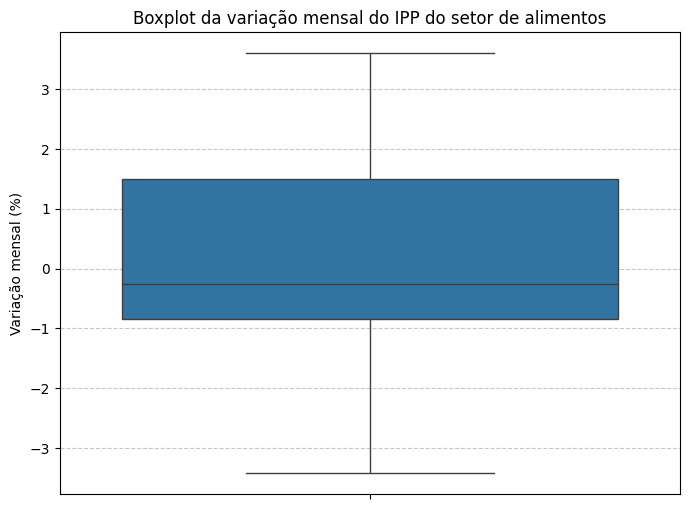

In [13]:
# 6. Construir um boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=df[var_ipp])

# 7. Colocar título e eixo Y
plt.title('Boxplot da variação mensal do IPP do setor de alimentos')
plt.ylabel('Variação mensal (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### 8. Interpretação do Boxplot

O boxplot da variação mensal do IPP para o setor de alimentos fornece uma representação visual clara da distribuição dos dados:

*   **Mediana (linha central da caixa):** A linha horizontal dentro da caixa representa a mediana (Q2) dos dados, que é de aproximadamente -0.26%. Isso significa que metade dos meses teve uma variação de preços igual ou inferior a esse valor, enquanto a outra metade teve uma variação igual ou superior.

*   **Primeiro Quartil (Q1 - base da caixa):** A parte inferior da caixa indica o primeiro quartil (Q1), aproximadamente -0.85%. Isso significa que 25% dos meses registraram uma variação de preços menor ou igual a -0.85%.

*   **Terceiro Quartil (Q3 - topo da caixa):** A parte superior da caixa representa o terceiro quartil (Q3), cerca de 1.49%. Isso indica que 75% dos meses tiveram uma variação de preços menor ou igual a 1.49%.

*   **Caixa do Boxplot:** A caixa em si abrange o intervalo entre Q1 e Q3, ou seja, a **amplitude interquartílica (AIQ = 2.34%)**. Ela contém os 50% centrais das observações, mostrando onde a maioria das variações mensais de preços se concentra. Uma caixa mais curta indicaria menor variabilidade nos 50% centrais, enquanto uma caixa mais longa, como esta, sugere maior dispersão.

*   **"Bigodes" (linhas estendidas):** As linhas que se estendem da caixa (os "bigodes") indicam a faixa esperada dos dados. Eles geralmente se estendem até 1.5 vezes a AIQ de Q1 e Q3, ou até o menor/maior valor que não é considerado atípico. No nosso gráfico, os bigodes mostram o limite da maioria dos dados.

*   **Possíveis Valores Atípicos (Outliers):** Observa-se a presença de pontos individuais fora dos "bigodes" do boxplot. Estes são considerados **valores atípicos (outliers)**. Eles representam meses em que a variação mensal do IPP foi significativamente diferente da maioria dos outros períodos. No contexto dos preços da indústria de alimentos, esses outliers podem indicar eventos econômicos incomuns, como:
    *   **Variações positivas muito altas:** Podem ser resultado de choques de oferta (escassez), aumentos abruptos nos custos de produção (matérias-primas, energia), ou forte demanda. Essas variações podem ter um impacto considerável na inflação dos alimentos.
    *   **Variações negativas muito baixas (ou altas deflações):** Poderiam indicar excesso de oferta, queda nos custos de produção, ou períodos de intensa guerra de preços. Embora menos comuns em contextos inflacionários, deflações acentuadas podem ter implicações para a rentabilidade do setor.

A análise desses outliers é crucial para identificar períodos de instabilidade ou eventos específicos que influenciaram o setor de alimentos, permitindo uma investigação mais aprofundada das causas por trás dessas variações extremas.

#Como determinamos se há observações atípicas em uma base de dados?



Para determinar se há observações atípicas (também chamadas de outliers) em uma base de dados, especialmente com variáveis quantitativas, um método amplamente utilizado, e que já está detalhado no seu notebook (célula MbYem09Rlror), é o critério do boxplot e da amplitude interquartílica (AIQ).

Funciona da seguinte forma:

Calcule os quartis: Primeiro, você determina o Primeiro Quartil (Q1), o Segundo Quartil (Q2, que é a mediana) e o Terceiro Quartil (Q3) da sua variável de interesse.

Calcule a Amplitude Interquartílica (AIQ): A AIQ é a diferença entre o Terceiro Quartil e o Primeiro Quartil (AIQ = Q3 - Q1). Ela representa a dispersão dos 50% centrais dos seus dados.

Defina os Limites: A partir da AIQ, você calcula dois limites:

Limite Inferior = Q1 - 1,5 × AIQ

Limite Superior = Q3 + 1,5 × AIQ

Identifique Outliers: Qualquer valor que esteja abaixo do Limite Inferior ou acima do Limite Superior é considerado uma potencial observação atípica ou outlier.

No boxplot, esses valores atípicos são geralmente representados por pontos individuais que ficam fora dos "bigodes" do gráfico. No seu notebook, na interpretação do boxplot (célula fdcd3aca), já identificamos e discutimos a presença desses pontos para a 'Variação mensal do IPP - Alimentos (%)', o que indica meses com variações de preço significativamente incomuns.